![header](content/img/header.PNG)
# Part 3 : Mapping discharge gauge station to glofas cell

Welcome to the companion Jupyter notebook of the 5th ICAR training -  Interactive session 1 (part 2): Observations VS Simulations.
This notebook will walk you through how to:
* Map the station to the correct Glofas cell.
* Download glofas climatology of the corresponding cell.
* Visualize observed and analysis discharge data.
* Calculate and assess hydrological model performance metrics.
* Fit Gumbel distribution and calculate the thresholds.
* Visualize the thresholds and the hydrograph of the whole period.
* Read static data (flood thresholds and upstream area) .
* Compare and vizuialise station based thresholds against glofas thresholds .

Suppose you have discharge observations from multiple stations across your area of interest, and you want to compare historical model simulations against your measured data. This notebook will demonstrate how to perform this comparison step by step.
For more details please refer to the confluence page: https://confluence.ecmwf.int/display/CEMS/Mapping+locations+onto+CEMS-Flood+river+networks

To illustrate the process, we will use an observation station located in northern Morocco that is present in both GLOFAS and EFAS datasets. Below are the station metadata details:
* Station Name: Hajra Benkarrich
* River: Oued Elkbir
* Longitude: -5.447934
* Latitude: 35.514368
* Drainage Area: 498 km²
* Catchment: Coastal
* Continent: Africa
* Country Code: MAR
* Country Name: Morocco

## Further instructions
* Start a QGIS project to correctly map the station.
* Download the glofas_uparea.nc file (https://confluence.ecmwf.int/display/CEMS/Auxiliary+Data)
* In this notebook, we will only present the results. Please select a station of your choice and follow the instructions provided to perform the analysis step by step.


<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>When mapping the station using the provider's coordinates, you may notice a slight discrepancy in position compared to GLOFAS coordinates. This difference occurs due to variations in spatial resolution between datasets.</strong>
</div>

![Qgis1](content/img/Qgis1.PNG)

<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>Import the uparea NetCDF file into QGIS and check if the station point falls within the same grid cell as the corresponding GLOFAS coordinates. </strong></div>

![Qgis2](content/img/Qgis2.PNG)

<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>Ensure that the upstream area of the station, as provided by the data provider, closely matches the upstream area of the corresponding GLOFAS cell. </strong>
</div>

![Qgis2](content/img/Qgis2.PNG)

<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>For more details about mapping stations , please see <a href=https://confluence.ecmwf.int/display/CEMS/Mapping+locations+onto+CEMS-Flood+river+networks>Mapping stations onto CEMS Flood River Network</a>  </strong>
</div>

In [1]:
import os
import glob
# CDS API
import cdsapi
from tqdm import tqdm

# Libraries for working with multidimensional arrays
import numpy as np
import xarray as xr
import pandas as pd

# Libraries for plotting and visualising data
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#metrics
from scipy.stats import pearsonr
from scipy.stats import gumbel_r

In [2]:
# Home directory
DATADIR = os.path.expanduser("~")

## Download GloFAS climatology of the corresponding cell

In [ ]:
## === Retrieve GloFAS Climatology ===

c = cdsapi.Client()

DATASET = 'cems-glofas-historical'
YEARS = ['%02d' % (mn) for mn in range(1990, 2026)]
MONTHS = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
DAYS = ['%02d' % (mn) for mn in range(1, 32)]

for year in tqdm(YEARS, desc="Downloading data", unit="year"):
    REQUEST = {
        'system_version': 'version_4_0',
        'product_type': 'consolidated',
        'hydrological_model': 'lisflood',
        'variable': 'river_discharge_in_the_last_24_hours',
        'hyear': year,
        'hmonth': MONTHS,
        'hday': DAYS,
        'data_format': "grib",
        "area": [35.72, -5.63, 35.37, -5.26],
        'download_format': "unarchived"
    }
    
    # Download file for the given year
    c.retrieve(DATASET, REQUEST).download(f'{DATADIR}{DATASET}_{year}.grib')

### Read multiple glofas historical data grib files

In [3]:

grib_files = sorted(glob.glob(os.path.join(DATADIR, "cems-glofas-historical_*.grib")))
glofas_data = xr.open_mfdataset(grib_files, engine="cfgrib", combine="by_coords")

#Read the observations csv file
Gauge_station = pd.read_csv('/perm/ecm3644/efas/efas-observations/Qobs_24.csv', parse_dates=['Timestamp'])

<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>After mapping the station to the correct GLOFAS cell, we need to extract the coordinates of that cell in order to compare it with our time series. <br>
We assume that you’ve already completed this step and identified the coordinates of the cell that best represents the station.<br>
If you extract the coordinates of the GLOFAS cell from QGIS, the longitude will be in the range [-180, 180], whereas the GRIB files use longitudes in the range [0, 360]. Therefore, you need to add 360 to the longitude value if it's negative, to match the GRIB file convention.</strong></div>

<div style="padding: 20px; background-color: #fdd835; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>GRIB edition 1 regulates that the longitude can be in either [-180, 180] or [0,360], but GRIB edition 2 regulates that the longitude can only be in the interval [0,360]. ecCodes does comply with these regulations and in the case of GRIB 2, it will scale the longitude to fall in the interval [0,360]. ecCodes does not offer an edition-independent view of the longitude because of the uncertainty brought by GRIB 1, where you do not know what interval a longitude is in exactly.</strong></div>

In [4]:
Long=354.575 #(Long=lon+360)
lon=-5.425
Lat=35.525

In [5]:
# Convert xarray datarray timeseries to dataframe
Gauge_station['Timestamp'] = pd.to_datetime(Gauge_station['Timestamp'])

Timeserie = glofas_data.sel(latitude=Lat, longitude=Long, method='nearest')
Timeserie_dataframe = Timeserie[['time', 'dis24']].to_dataframe().reset_index()

In [6]:
# Convert xarray DataArray to DataFrame
glofas_timeseries = Timeserie_dataframe[['time', 'dis24']]
Gauge_station.rename(columns={"Timestamp": "time", "6954": "observational_discharge"}, inplace=True)
glofas_timeseries.rename(columns={"dis24": "glofas_discharge"}, inplace=True)
# Merge both datasets on the "time"
observed_vs_analysis = pd.merge(Gauge_station, glofas_timeseries, on="time", how="outer")

/etc/ecmwf/ssd/ssd1/jupyterhub/ecm3644-jupyterhub/tmpdirs/ecm3644.42432043/ipykernel_2220448/1674555776.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  glofas_timeseries.rename(columns={"dis24": "glofas_discharge"}, inplace=True)



## Performance metric definitions and calculations

In [7]:
# Extract observed and simulated discharge
observed_vs_analysis = observed_vs_analysis.dropna(subset=['observational_discharge', 'glofas_discharge'])

obs = observed_vs_analysis['observational_discharge'].values
sim = observed_vs_analysis['glofas_discharge'].values

# Define and calculate performance metric functions
def kge(obs, sim):
    """ Modified KGE Gupta, H.V., Kling, H., Yilmaz, K.K. and Martinez, G.F. (2009) Decomposition of the Mean Squared Error and NSE Performance Criteria: Implications for Improving Hydrological Modelling. Journal of Hydrology, 377, 80-91."""
    """ https://www.sciencedirect.com/science/article/abs/pii/S0022169409004843?via%3Dihub """
    r = np.corrcoef(obs, sim)[0, 1]  # Correlation
    beta = np.mean(sim) / np.mean(obs)  # Bias
    gamma = (np.std(sim) / np.mean(sim)) / (np.std(obs) / np.mean(obs))  # Variability
    return 1 - np.sqrt((r - 1) ** 2 + (beta - 1) ** 2 + (gamma - 1) ** 2) #Modified KGE
    

def nse(obs, sim):
    """ """
    return 1 - (np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2))

def bias(obs, sim):
    return np.mean(sim) / np.mean(obs)

def variability(obs, sim):
    return (np.std(sim) / np.mean(sim)) / (np.std(obs) / np.mean(obs))

# Compute performance metrics
performance_metrics = {
    "KGE": kge(obs, sim),
    "NSE": nse(obs, sim),
    "Bias": bias(obs, sim),
    "Variability": variability(obs, sim),
    "Correlation": pearsonr(obs, sim)[0]
}



## Visualize Observed and Simulated Discharge Data



 Model Performance Metrics:
         KGE       NSE      Bias  Variability  Correlation
0  0.556809  0.263261  0.891554     0.934871     0.575246


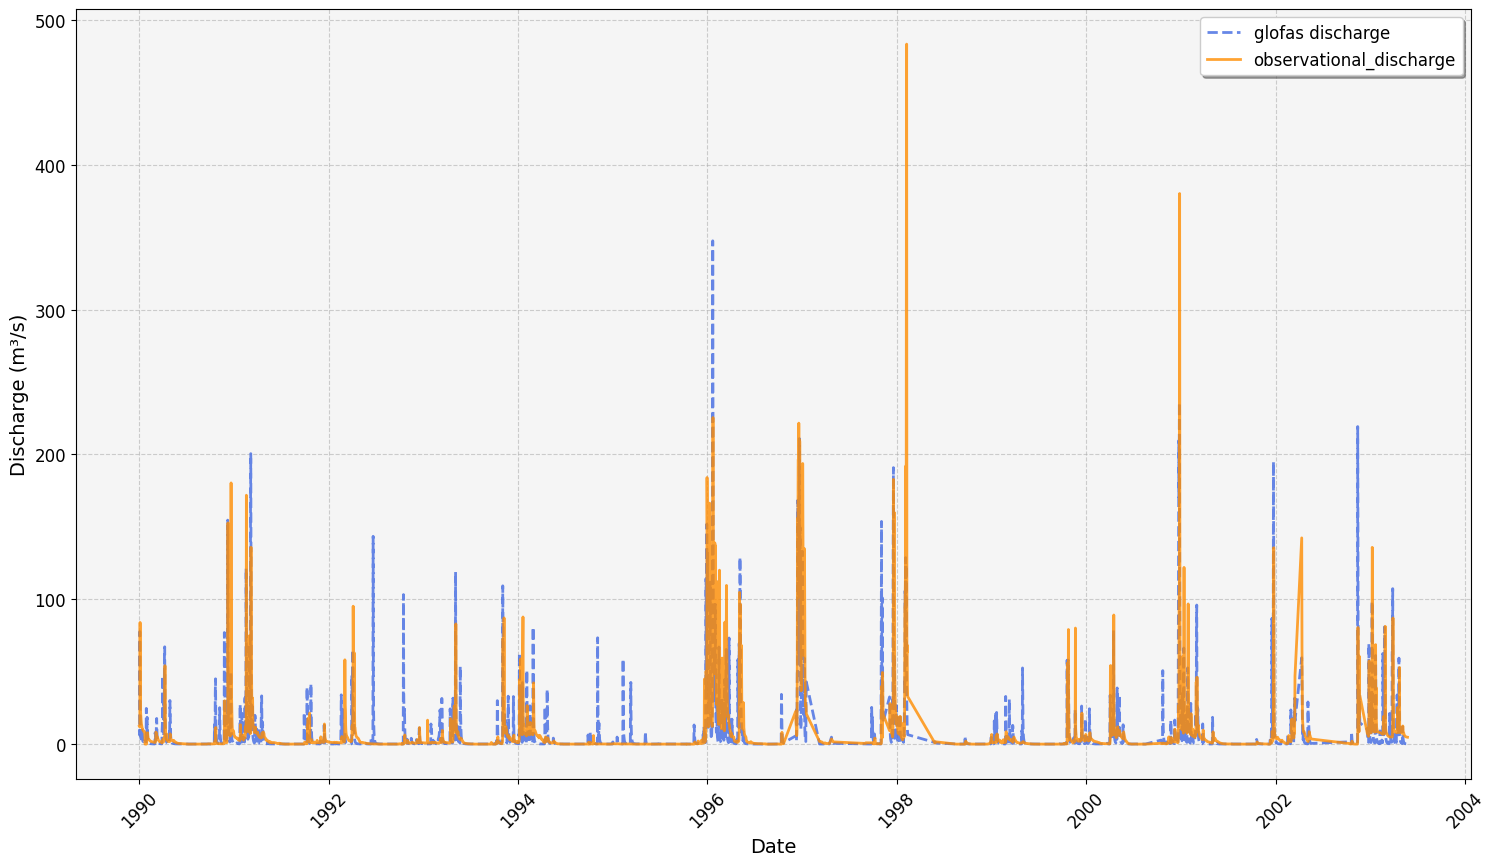

In [9]:
# Convert to DataFrame
performance_df = pd.DataFrame(performance_metrics, index=[0])
print("\n Model Performance Metrics:\n", performance_df)

# glofas Vs observational timeseries 

plt.figure(figsize=(18, 10))
plt.plot(observed_vs_analysis['time'], observed_vs_analysis['glofas_discharge'], label="glofas discharge", linestyle="--", linewidth=2, color="royalblue", alpha=0.8)
plt.plot(observed_vs_analysis['time'], observed_vs_analysis['observational_discharge'], label="observational_discharge", linestyle="-", linewidth=2, color="darkorange", alpha=0.8)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Discharge (m³/s)", fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)

plt.grid(True, linestyle="--", alpha=0.6)

plt.gca().set_facecolor('#f5f5f5')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()


## Visualize hydrological model performance metrics.

In [10]:
class SpeedometerPlot:
    darkestblue = [i / 255. for i in (57, 16, 139)]
    darkerblue = [i / 255. for i in (58, 68, 214)]
    lighterblue = [i / 255. for i in (86, 148, 254)]
    lightestblue = [i / 255. for i in (160, 201, 254)]
    grey = [i / 255. for i in (196, 198, 201)]

    def __init__(self):
        self.colors_nonsym = [self.grey, self.lightestblue, self.lighterblue, self.darkerblue, self.darkestblue]
        self.labels_nonsym = ['<0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

    def rot_text(self, ang):
        return np.degrees(np.radians(ang) - np.radians(90))

    def degree_range(self, n):
        start = np.linspace(0, 180, n + 1)[:-1]
        end = np.linspace(0, 180, n + 1)[1:]
        mid_points = start + ((end - start) / 2.)
        return np.c_[start, end], mid_points

    def gauge(self, ax, labels, colors, arrow=0.5, title='', score=None, fontsize=14):
        if arrow > 1:
            raise ValueError("Arrow position must be between 0 and 1")

        n_labels = len(labels)
        ang_range, mid_points = self.degree_range(n_labels)
        labels = labels[::-1]

        for ang, c in zip(ang_range, colors):
            ax.add_patch(patches.Wedge((0., 0.), .4, *ang, facecolor='white', lw=2))
            ax.add_patch(patches.Wedge((0., 0.), .4, *ang, width=0.20, edgecolor='white', facecolor=c, lw=2, alpha=1.0))

        for i, (mid, lab) in enumerate(zip(mid_points, labels)):
            text_color = 'white' if colors[i] in [self.darkerblue, self.darkestblue] else 'black'
            ax.text(0.3 * np.cos(np.radians(mid)), 0.3 * np.sin(np.radians(mid)), lab,
                    ha='center', va='center', fontsize=fontsize - 2, fontweight='bold',
                    rotation=self.rot_text(mid), color=text_color)

        ax.text(0, 0.01, title, ha='center', va='center', fontsize=fontsize, fontweight='bold')

        pos = 180 - arrow * 180
        ax.arrow(0, 0, 0.3 * np.cos(np.radians(pos)), 0.3 * np.sin(np.radians(pos)),
                 width=0.01, head_width=0.02, head_length=0.05, facecolor='black', edgecolor='white')

        if score is not None:
            ax.text(0.45 * np.cos(np.radians(pos)), 0.45 * np.sin(np.radians(pos)),
                    f"{score:.2f}", ha='center', va='center', fontsize=fontsize + 2, fontweight='bold',
                    rotation=self.rot_text(pos), color='black')

        ax.set_frame_on(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('equal')


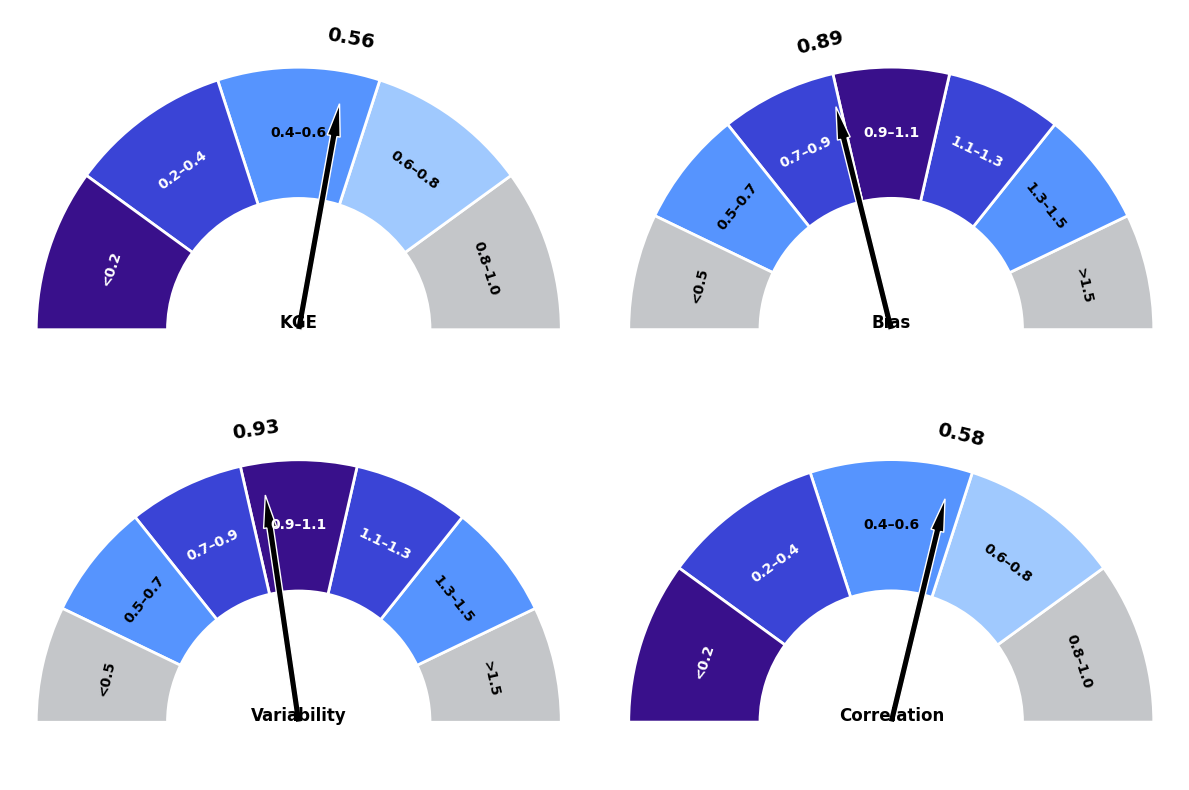

In [11]:
# Normalization rules each metric
gauge_config = {
    "KGE": {
        "labels": ['<0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0'],
        "colors": SpeedometerPlot().colors_nonsym,
        "normalize": lambda x: np.clip(x, 0, 1)  # KGE in [0, 1]
    },
    "Correlation": {
        "labels": ['<0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0'],
        "colors": SpeedometerPlot().colors_nonsym,
        "normalize": lambda x: np.clip(x, 0, 1)
    },
    "Bias": {
        "labels": ['<0.5', '0.5–0.7', '0.7–0.9', '0.9–1.1', '1.1–1.3', '1.3–1.5', '>1.5'],
        "colors": [
            SpeedometerPlot().grey, SpeedometerPlot().lighterblue,
            SpeedometerPlot().darkerblue, SpeedometerPlot().darkestblue,
            SpeedometerPlot().darkerblue, SpeedometerPlot().lighterblue,
            SpeedometerPlot().grey
        ],
        "normalize": lambda x: np.clip((x - 0.3) / (1.7 - 0.3), 0, 1)  # bias ∈ [0.3, 1.7]
    },
    "Variability": {
        "labels": ['<0.5', '0.5–0.7', '0.7–0.9', '0.9–1.1', '1.1–1.3', '1.3–1.5', '>1.5'],
        "colors": [
            SpeedometerPlot().grey, SpeedometerPlot().lighterblue,
            SpeedometerPlot().darkerblue, SpeedometerPlot().darkestblue,
            SpeedometerPlot().darkerblue, SpeedometerPlot().lighterblue,
            SpeedometerPlot().grey
        ],
        "normalize": lambda x: np.clip((x - 0.3) / (1.7 - 0.3), 0, 1)
    }
}
gauge_plotter = SpeedometerPlot()

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()  # Flatten to loop easily

metrics_to_plot = [m for m in performance_metrics if m in gauge_config]

for i, metric in enumerate(metrics_to_plot):
    value = performance_metrics[metric]
    config = gauge_config[metric]
    arrow_value = config["normalize"](value)
    labels = config["labels"]
    colors = config["colors"]

    gauge_plotter.gauge(ax=axs[i],
                        labels=labels,
                        colors=colors,
                        arrow=arrow_value,
                        title=metric,
                        score=value,
                        fontsize=12)


plt.tight_layout()
plt.show()



## Fit Gumbel Distribution, Estimate Return Period Thresholds, and Visualize the Hydrograph

 Extended Flood Thresholds (Gumbel):
                 Flood Thresholds
1.5-year Flood        132.517768
2-year Flood          164.007374
5-year Flood          241.502410
10-year Flood         292.810867
20-year Flood         342.027171
50-year Flood         405.732628
100-year Flood        453.470903
200-year Flood        501.034989
500-year Flood        563.786769


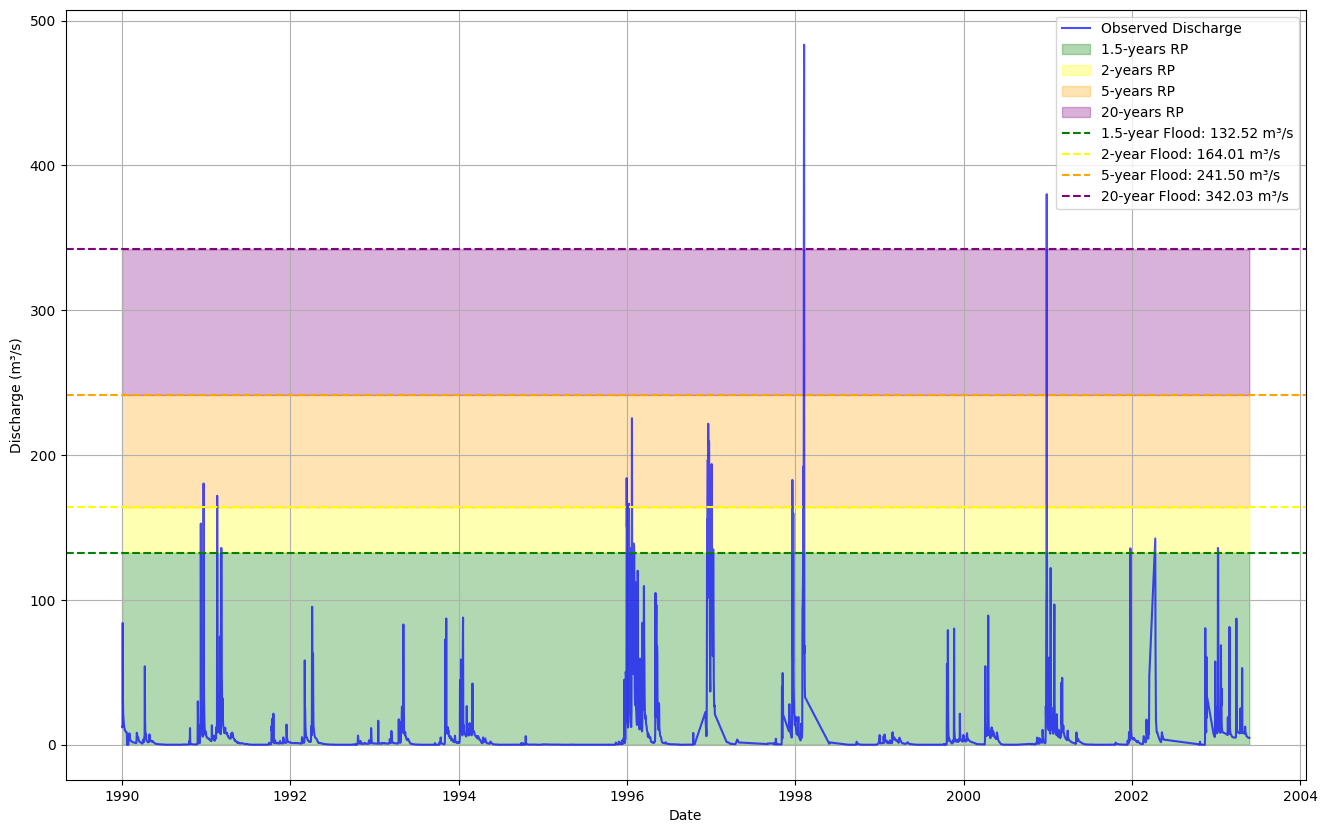

In [12]:
# extract the Annual Maximum Series
observed_vs_analysis['year'] = observed_vs_analysis['time'].dt.year
annual_max = observed_vs_analysis.groupby('year')['observational_discharge'].max().values

# Define return periods
extended_return_periods = [1.5,2, 5, 10, 20, 50, 100, 200, 500]

# Fit Gumbel Distribution
params_gumbel = gumbel_r.fit(annual_max)
gumbel_thresholds = {f"{rp}-year Flood": gumbel_r.ppf(1 - 1/rp, *params_gumbel) for rp in extended_return_periods}

# thresholds to DataFrame
threshold_df = pd.DataFrame(gumbel_thresholds, index=["Flood Thresholds"]).T
print(" Extended Flood Thresholds (Gumbel):\n", threshold_df)

# Pallette
colors = plt.cm.viridis(np.linspace(0, 1, len(extended_return_periods)))

# observed discharge with return period thresholds
plt.figure(figsize=(16, 10))
plt.plot(observed_vs_analysis['time'], observed_vs_analysis['observational_discharge'], label="Observed Discharge", color="blue", alpha=0.7)

#threshold values
threshold_1_5 = gumbel_thresholds['1.5-year Flood']
threshold_2 = gumbel_thresholds['2-year Flood']
threshold_5 = gumbel_thresholds['5-year Flood']
threshold_20 = gumbel_thresholds['20-year Flood']

# Fill areas between thresholds with different colors
plt.fill_between(observed_vs_analysis['time'], 0, threshold_1_5, color='green', alpha=0.3, label="1.5-years RP")
plt.fill_between(observed_vs_analysis['time'], threshold_1_5, threshold_2, color='yellow', alpha=0.3, label="2-years RP")
plt.fill_between(observed_vs_analysis['time'], threshold_2, threshold_5, color='orange', alpha=0.3, label="5-years RP")
plt.fill_between(observed_vs_analysis['time'], threshold_5, threshold_20, color='purple', alpha=0.3, label="20-years RP")
threshold_colors = {
    '1.5-year Flood': 'green',
    '2-year Flood':   'yellow',
    '5-year Flood':   'orange',
    '20-year Flood':  'purple',
}
for i, (label, value) in enumerate(gumbel_thresholds.items()):
    if label in ['1.5-year Flood','2-year Flood', '5-year Flood', '20-year Flood']:
        plt.axhline(y=value, linestyle="--", color=threshold_colors[label], label=f"{label}: {value:.2f} m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()

## Read GloFAS threshold files .

In [13]:
return_periods = [1.5, 2, 5, 10, 20, 50, 100, 200, 500]
base_path = os.path.expanduser("/perm/ecm3644/glofas/Static_maps/")

thresholds = {}
for rp in return_periods:
   file_path = os.path.join(base_path, f"flood_threshold_glofas_v4_rl_{rp}.nc")
   thresholds[rp] = xr.open_dataset(file_path)
for rp, ds in thresholds.items():
   print(f"{rp}-year threshold data variables:", ds.data_vars)


1.5-year threshold data variables: Data variables:
    rl_1.5   (lat, lon) float64 173MB ...
2-year threshold data variables: Data variables:
    rl_2.0   (lat, lon) float64 173MB ...
5-year threshold data variables: Data variables:
    rl_5.0   (lat, lon) float64 173MB ...
10-year threshold data variables: Data variables:
    rl_10.0  (lat, lon) float64 173MB ...
20-year threshold data variables: Data variables:
    rl_20.0  (lat, lon) float64 173MB ...
50-year threshold data variables: Data variables:
    rl_50.0  (lat, lon) float64 173MB ...
100-year threshold data variables: Data variables:
    rl_100.0  (lat, lon) float64 173MB ...
200-year threshold data variables: Data variables:
    rl_200.0  (lat, lon) float64 173MB ...
500-year threshold data variables: Data variables:
    rl_500.0  (lat, lon) float64 173MB ...


## Comparison of Observational and GloFAS Thresholds

GloFAS Thresholds: {'1.5-year Flood': 119.89029416284691, '2-year Flood': 144.10539621498776, '5-year Flood': 203.69808226893315, '10-year Flood': 243.15362576735413, '20-year Flood': 281.00033036137705, '50-year Flood': 329.9890073622495, '100-year Flood': 366.69912702507384, '200-year Flood': 403.27529762771024, '500-year Flood': 451.53060948024796}


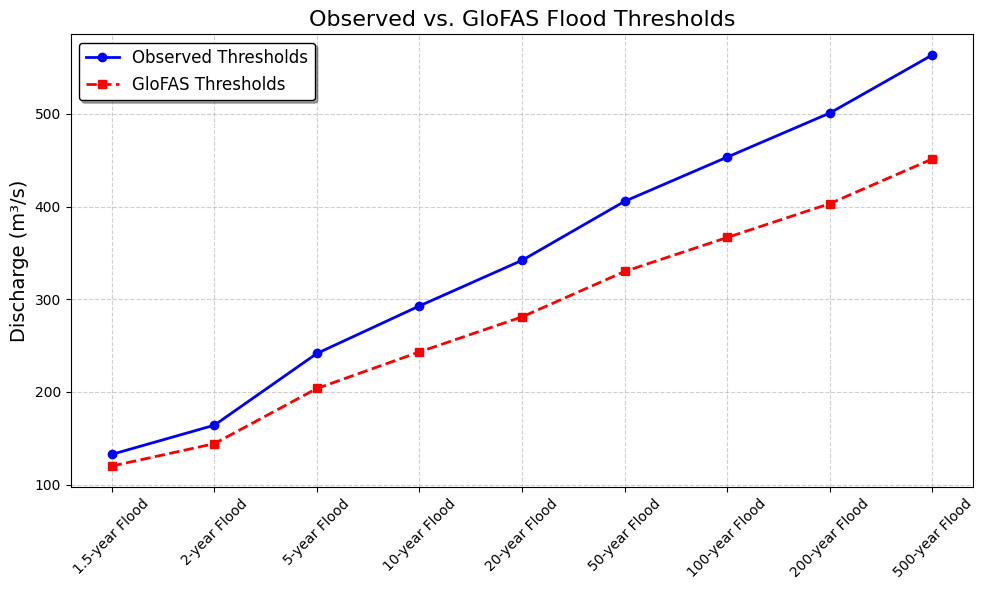

In [14]:
# Observed thresholds
observed_thresholds = threshold_df["Flood Thresholds"].to_dict()
# Glofas thresholds
glofas_thresholds = {}
for rp, ds in thresholds.items():
    varname = list(ds.data_vars)[0]  # Automatically find the variable name
    value = ds[varname].sel(lat=Lat, lon=lon, method="nearest").values.item()
    label = f"{int(rp) if isinstance(rp, float) and rp.is_integer() else rp}-year Flood"
    glofas_thresholds[label] = value

print("GloFAS Thresholds:", glofas_thresholds)

comparison_df = pd.DataFrame({
    "Observed (Gauge)": [observed_thresholds.get(k, None) for k in glofas_thresholds.keys()],
    "GloFAS (Simulated)": list(glofas_thresholds.values())
}, index=glofas_thresholds.keys())

plt.figure(figsize=(10, 6))
plt.plot(comparison_df.index, comparison_df["Observed (Gauge)"], marker="o", linestyle="-", label="Observed Thresholds", color="blue", linewidth=2)
plt.plot(comparison_df.index, comparison_df["GloFAS (Simulated)"], marker="s", linestyle="--", label="GloFAS Thresholds", color="red", linewidth=2)

plt.ylabel("Discharge (m³/s)", fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=12, loc="upper left", frameon=True, shadow=True, edgecolor="black")
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Observed vs. GloFAS Flood Thresholds", fontsize=16)
plt.tight_layout()
plt.show()
